# Customer lifetime value for a check-to-virtual-card program

An accounts payable (AP) automation platform pays merchants on behalf of its customers. Every merchant moved off paper check or ACH (automated clearing house) onto the virtual card rail earns the program interchange on each settled payment. Conversion is not free: outreach labor, onboarding incentives, and integration work all cost money, and converted merchants do not stay on the rail forever.

This notebook answers the two questions finance asks about the program:

1. How long do we keep a converted merchant on the rail?
2. What is a converted merchant worth, so we know the most we should spend converting one?

The companion [merchant retention study](../merchant_retention/) rebuilt enrollment history from change data capture (CDC) and defined the program North Star. Here that history arrives reconciled, and the job is valuation:

1. **Cohort retention**: conversion-month cohorts, a retention matrix, and the heatmap read.
2. **Survival curves**: median rail tenure by segment and onboarding channel, censoring handled.
3. **Customer lifetime value (CLV) four ways**: historical, basic, granular, and traditional, with the assumptions each one hides.
4. **Conversion spend ceilings**: CLV against per-channel conversion cost, the number the business acts on.
5. **Next-month revenue model**: recency, frequency, monetary (RFM) features, linear regression, root mean squared error (RMSE) and mean absolute error (MAE) on held-out data, and a statsmodels read of the coefficients.

Method follows the CLV chapter of DataCamp's Machine Learning for Marketing in Python (Karolis Urbonas): the same cohort pivot, the same three formula-based CLV variants, the same RFM snapshot preparation, and the same modeling steps, applied to a B2B (business-to-business) payments rail instead of online retail.

The dataset is synthetic and deterministic: `data/generate_dataset.py` documents every behavior the analysis is supposed to find. Program net revenue is modeled at 1.0% of settled volume (2.5% blended interchange, of which the program keeps 40%).

In [1]:
%matplotlib inline
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

ACCENT, SECONDARY, RULE, MUTED, PAPER = '#B4441E', '#8A7B63', '#D8CDBA', '#B9AC96', '#FDF8F0'
CMAP = sns.blend_palette([PAPER, '#E9C9B4', ACCENT], as_cmap=True)
CMAP.set_bad('#F1EAE0')
plt.rcParams.update({
    'figure.dpi': 88, 'savefig.dpi': 100, 'figure.figsize': (10.9, 3.7),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': RULE, 'axes.grid': True, 'grid.color': RULE, 'grid.alpha': 0.45,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
IMG = Path('images'); IMG.mkdir(exist_ok=True)

NET_TAKE = 0.010           # net revenue per settled $: 2.5% interchange x 40% program share
LIFESPAN_MONTHS = 36       # planning lifespan for the formula-based CLVs
ANCHOR = pd.Period('2026-01', freq='M')   # analysis date: 2026-01-01

merchants = pd.read_csv('data/merchants.csv')
payments = pd.read_csv('data/vc_payments.csv')

merchants['conv'] = pd.PeriodIndex(pd.to_datetime(merchants.conversion_month), freq='M')
merchants['churn'] = pd.PeriodIndex(pd.to_datetime(merchants.churn_month), freq='M')
# months on the rail: churned -> conversion..churn-1; still enrolled -> censored at the anchor
merchants['dur'] = [(ch - cv).n if pd.notna(ch) else (ANCHOR - cv).n
                    for cv, ch in zip(merchants.conv, merchants.churn)]
merchants['churned'] = merchants.churn.notna()

payments['month'] = pd.PeriodIndex(pd.to_datetime(payments.month), freq='M')
payments['net_revenue'] = payments.volume * NET_TAKE
pay = payments.merge(
    merchants[['merchant_id', 'segment', 'onboarding_channel', 'converted_from', 'conv']],
    on='merchant_id')

print(f'{len(merchants):,} converted merchants | {merchants.churned.sum():,} churned back off the rail | '
      f'{len(payments):,} active merchant-months | window {payments.month.min()}..{payments.month.max()}')
merchants.drop(columns=['conv', 'churn']).head()

3,892 converted merchants | 1,842 churned back off the rail | 22,100 active merchant-months | window 2023-01..2025-12


,merchant_id,segment,converted_from,onboarding_channel,conversion_month,churn_month,dur,churned
0,M10001,regular,Check,outreach,2023-01-01,NaN,36,False
1,M10002,regular,ACH,integrated,2023-01-01,2024-03-01,14,True
2,M10003,occasional,Check,organic,2023-01-01,2023-08-01,7,True
3,M10004,regular,Check,integrated,2023-01-01,2025-08-01,31,True
4,M10005,regular,ACH,outreach,2023-01-01,2023-03-01,2,True


## 1. The program at a glance

First the monthly distribution of activity, the same first check the source material runs before any modeling: does the window contain growth, campaigns, seasonality that the models need to respect? Three things should be visible: steady conversion growth, the outreach campaign spike in January and February 2024, and the November-December settlement bump.

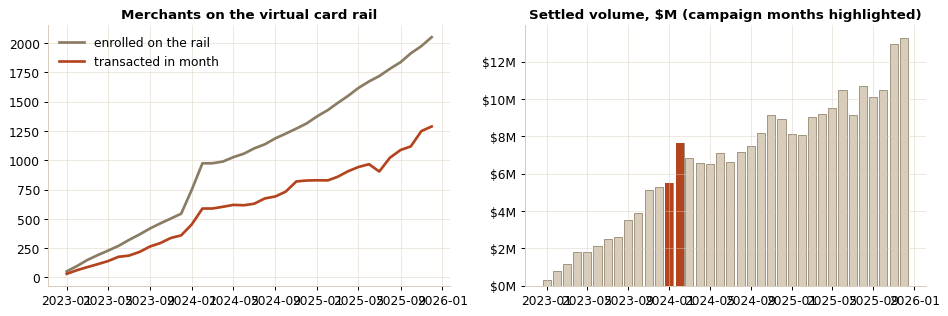

On average 414 enrolled merchants per month settle nothing: the occasional segment keeps the rail but skips months, which is why enrollment and activity are different lenses.


In [2]:
spine = pd.period_range('2023-01', '2025-12', freq='M')
enrolled = pd.Series(
    {m: ((merchants.conv <= m) & (~merchants.churned | (merchants.churn > m))).sum() for m in spine})
monthly = pay.groupby('month').agg(active=('merchant_id', 'nunique'), volume=('volume', 'sum'))
monthly = monthly.reindex(spine).fillna(0.0)

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7))
x = spine.to_timestamp()
axes[0].plot(x, enrolled.values, color=SECONDARY, lw=2.2, label='enrolled on the rail')
axes[0].plot(x, monthly.active.values, color=ACCENT, lw=2.2, label='transacted in month')
axes[0].set_title('Merchants on the virtual card rail')
axes[0].legend(frameon=False)
axes[1].bar(x, monthly.volume / 1e6, width=24, color=RULE, edgecolor=SECONDARY, lw=0.6)
for ym in ['2024-01', '2024-02']:
    i = spine.get_loc(pd.Period(ym, freq='M'))
    axes[1].bar(x[i], monthly.volume.iloc[i] / 1e6, width=24, color=ACCENT)
axes[1].set_title('Settled volume, $M (campaign months highlighted)')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}M'))
fig.tight_layout(); fig.savefig(IMG / 'monthly-program.png', dpi=100, bbox_inches='tight'); plt.show()

gap = enrolled - monthly.active
print(f'On average {gap.mean():,.0f} enrolled merchants per month settle nothing: '
      'the occasional segment keeps the rail but skips months, which is why '
      'enrollment and activity are different lenses.')

## 2. Cohort retention: how long converts stay on the rail

The source material's cohort recipe, applied to enrollment: assign each merchant an acquisition (here: conversion) month, pivot a count of merchants still on the rail by tenure month, take the first column as the cohort size, divide to get retention, and read `churn = 1 - retention` for free. Cells a cohort has not lived long enough to reach stay blank.

Two heatmaps: quarterly cohorts with annotations for the read, and the full monthly matrix for the shape. What to look for: the first-three-month cliff (merchants discovering reconciliation friction), the two visibly weaker campaign cohort rows in early 2024, and rows flattening after month 12 (survivors get sticky).

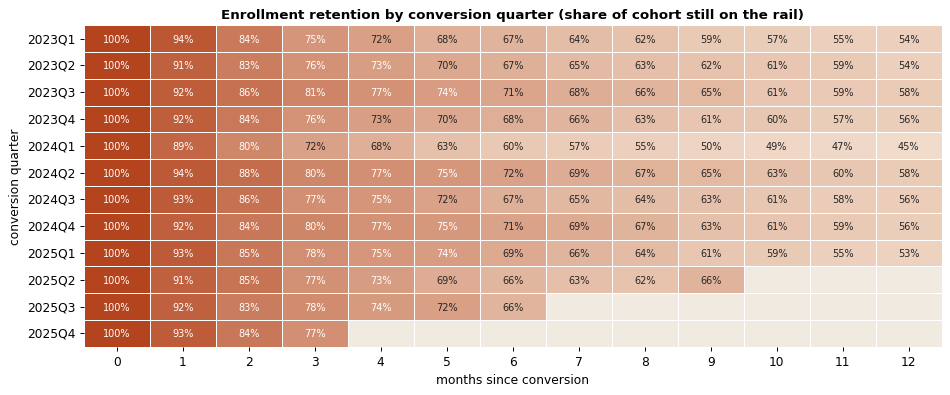

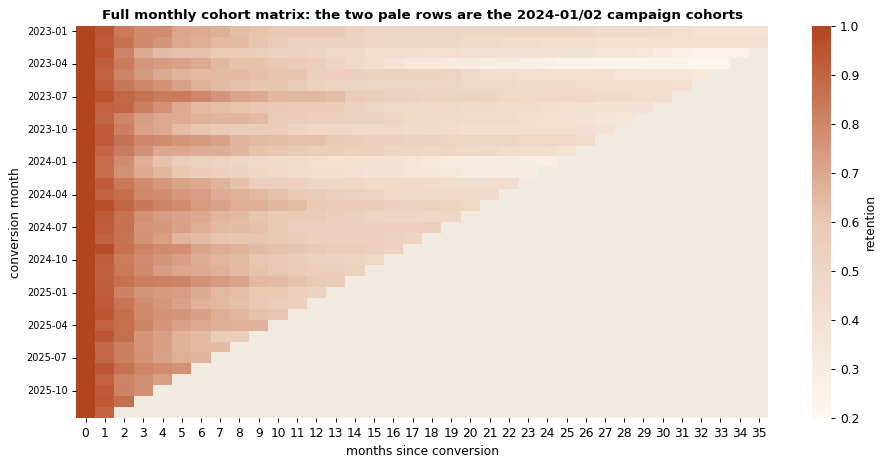

12-month enrollment retention: 54.7% average across cohorts, 42.4% for the two campaign cohorts.


In [3]:
MAX_T = 36
cohorts = sorted(merchants.conv.unique())
counts = pd.DataFrame(index=pd.PeriodIndex(cohorts, freq='M'), columns=range(MAX_T), dtype=float)
for c in cohorts:
    g = merchants[merchants.conv == c]
    observable = (ANCHOR - c).n          # tenure months this cohort has fully lived
    for t in range(MAX_T):
        if t == 0:
            counts.loc[c, 0] = len(g)                    # cohort size
        elif t <= observable:
            counts.loc[c, t] = (g.dur >= t).sum()        # still on the rail at start of month t
retention = counts.div(counts[0], axis=0)
churn_matrix = 1 - retention

cohort_sizes = counts[0]
qtr = retention.index.asfreq('Q')
retention_q = retention.groupby(qtr).mean()

fig, ax = plt.subplots(figsize=(10.9, 4.6))
sns.heatmap(retention_q.iloc[:, :13], annot=True, fmt='.0%', vmin=0.2, vmax=1.0,
            cmap=CMAP, linewidths=0.6, linecolor='white', cbar=False,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Enrollment retention by conversion quarter (share of cohort still on the rail)')
ax.set_xlabel('months since conversion'); ax.set_ylabel('conversion quarter')
ax.grid(False)
fig.tight_layout(); fig.savefig(IMG / 'retention-heatmap.png', dpi=100, bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(10.9, 5.4))
sns.heatmap(retention.astype(float), vmin=0.2, vmax=1.0, cmap=CMAP, cbar_kws={'label': 'retention'}, ax=ax)
ax.set_yticks(np.arange(0, len(retention), 3) + 0.5)
ax.set_yticklabels([str(p) for p in retention.index[::3]], rotation=0, fontsize=8)
ax.set_title('Full monthly cohort matrix: the two pale rows are the 2024-01/02 campaign cohorts')
ax.set_xlabel('months since conversion'); ax.set_ylabel('conversion month')
ax.grid(False)
fig.tight_layout(); plt.show()

m12 = retention[12].dropna()
camp = retention.loc[[pd.Period('2024-01', freq='M'), pd.Period('2024-02', freq='M')], 12].mean()
print(f'12-month enrollment retention: {m12.mean():.1%} average across cohorts, '
      f'{camp:.1%} for the two campaign cohorts.')

## 3. Survival curves and median rail tenure

Cohort curves answer per cohort; the business wants one number per segment and channel: "how long do we keep them?" A product-limit (Kaplan-Meier) estimate combines every cohort while handling censoring, so young cohorts stop masquerading as churn. The median is where each curve crosses 50%.

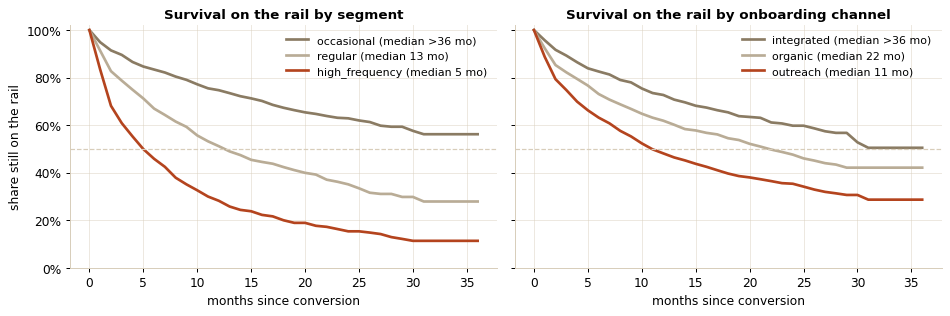

Blended: 58.0% of converts are still on the rail after 12 months, 44.7% after 24; median rail tenure 19 months.


In [4]:
def km_curve(dur, churned, horizon=MAX_T + 1):
    surv, out = 1.0, [1.0]
    for t in range(1, horizon):
        at_risk = (dur >= t).sum()
        events = ((dur == t) & churned).sum()
        if at_risk > 0:
            surv *= 1 - events / at_risk
        out.append(surv)
    return np.array(out)

def km_median(surv):
    below = np.nonzero(surv < 0.5)[0]
    return int(below[0]) if len(below) else None

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7), sharey=True)
for ax, col, colors in [
        (axes[0], 'segment', {'occasional': SECONDARY, 'regular': MUTED, 'high_frequency': ACCENT}),
        (axes[1], 'onboarding_channel', {'integrated': SECONDARY, 'organic': MUTED, 'outreach': ACCENT})]:
    for val, color in colors.items():
        g = merchants[merchants[col] == val]
        s = km_curve(g.dur.values, g.churned.values)
        m = km_median(s)
        label = f'{val} (median {m} mo)' if m else f'{val} (median >36 mo)'
        ax.plot(range(len(s)), s, color=color, lw=2.2, label=label)
    ax.axhline(0.5, color=RULE, lw=1, ls='--')
    ax.set_ylim(0, 1.02); ax.set_xlabel('months since conversion')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(frameon=False, fontsize=9)
axes[0].set_title('Survival on the rail by segment')
axes[1].set_title('Survival on the rail by onboarding channel')
axes[0].set_ylabel('share still on the rail')
fig.tight_layout(); fig.savefig(IMG / 'retention-curves.png', dpi=100, bbox_inches='tight'); plt.show()

s_all = km_curve(merchants.dur.values, merchants.churned.values)
print(f'Blended: {s_all[12]:.1%} of converts are still on the rail after 12 months, '
      f'{s_all[24]:.1%} after 24; median rail tenure {km_median(s_all)} months.')

## 4. What a merchant-month is worth

Revenue distributions before formulas. Settled volume per merchant-month is heavily right-skewed, so the second panel rescales to log; the skew uncrowds and the segment structure appears. The boxplots put numbers on it: the median high_frequency merchant-month is worth roughly two orders of magnitude more than the median occasional one.

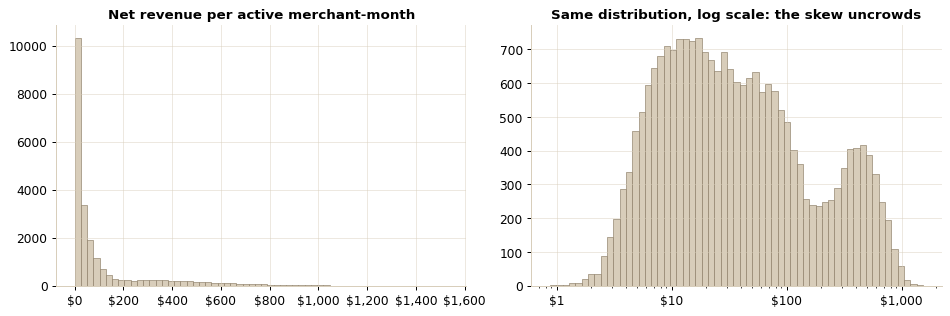

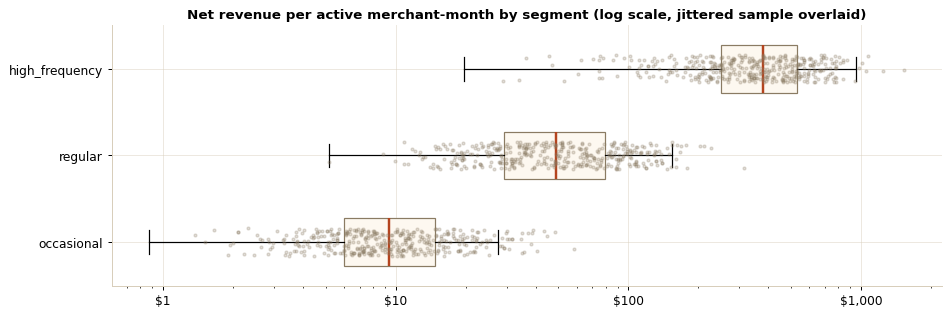

Average net revenue per active merchant-month: occasional: $11 | regular: $59 | high_frequency: $406


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7))
axes[0].hist(pay.net_revenue, bins=60, color=RULE, edgecolor=SECONDARY, lw=0.5)
axes[0].set_title('Net revenue per active merchant-month')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
bins = np.logspace(np.log10(max(pay.net_revenue.min(), 0.1)), np.log10(pay.net_revenue.max()), 60)
axes[1].hist(pay.net_revenue, bins=bins, color=RULE, edgecolor=SECONDARY, lw=0.5)
axes[1].set_xscale('log')
axes[1].set_title('Same distribution, log scale: the skew uncrowds')
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
fig.tight_layout(); plt.show()

order = ['occasional', 'regular', 'high_frequency']
fig, ax = plt.subplots(figsize=(10.9, 3.7))
data = [pay.loc[pay.segment == s, 'net_revenue'] for s in order]
bp = ax.boxplot(data, vert=False, showfliers=False, widths=0.55, patch_artist=True,
                medianprops={'color': ACCENT, 'lw': 2})
for box in bp['boxes']:
    box.set(facecolor=PAPER, edgecolor=SECONDARY)
for i, d in enumerate(data):                      # jittered sample overlay
    samp = d.sample(min(400, len(d)), random_state=7)
    ax.scatter(samp, np.full(len(samp), i + 1) + np.random.default_rng(7).uniform(-0.16, 0.16, len(samp)),
               s=6, alpha=0.25, color=SECONDARY, zorder=3)
ax.set_yticklabels(order); ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Net revenue per active merchant-month by segment (log scale, jittered sample overlaid)')
fig.tight_layout(); plt.show()

seg_month = pay.groupby('segment').net_revenue.mean().reindex(order)
print('Average net revenue per active merchant-month:',
      ' | '.join(f'{s}: ${v:,.0f}' for s, v in seg_month.items()))

## 5. Historical CLV

The simplest measure: sum what each merchant has actually delivered to date (revenue times margin, already applied in the net take). Two known problems, straight from the source material: it ignores tenure, retention, and churn (a merchant converted last quarter looks cheap next to a three-year veteran), and it says nothing about future revenue for recent converts. Useful as a floor and a reconciliation total, not as a planning number.

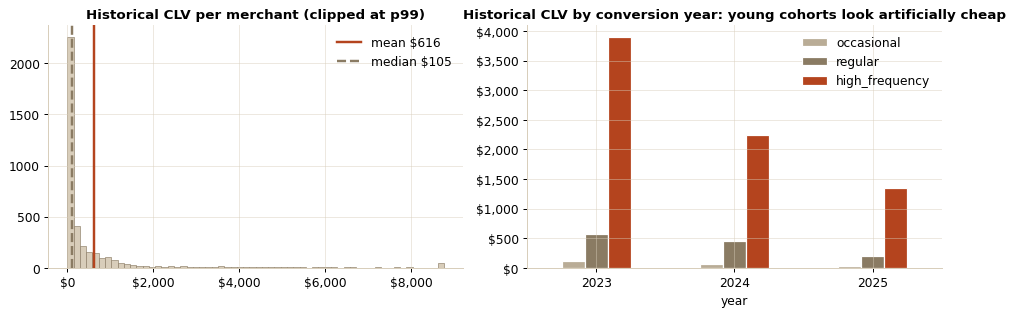

Realized net revenue to date: $2,396,367 across 3,892 converts (mean $616, median $105).


In [6]:
hist_clv = pay.groupby('merchant_id').net_revenue.sum().reindex(merchants.merchant_id).fillna(0.0)
merchants['historical_clv'] = hist_clv.values

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.7))
axes[0].hist(hist_clv.clip(upper=hist_clv.quantile(0.99)), bins=60, color=RULE, edgecolor=SECONDARY, lw=0.5)
axes[0].axvline(hist_clv.mean(), color=ACCENT, lw=2, label=f'mean ${hist_clv.mean():,.0f}')
axes[0].axvline(hist_clv.median(), color=SECONDARY, lw=2, ls='--', label=f'median ${hist_clv.median():,.0f}')
axes[0].legend(frameon=False)
axes[0].set_title('Historical CLV per merchant (clipped at p99)')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
by_year = merchants.assign(year=merchants.conv.map(lambda p: p.year)).groupby(['year', 'segment']).historical_clv.mean().unstack()
by_year[ ['occasional', 'regular', 'high_frequency'] ].plot.bar(
    ax=axes[1], color=[MUTED, SECONDARY, ACCENT], edgecolor='white', rot=0)
axes[1].set_title('Historical CLV by conversion year: young cohorts look artificially cheap')
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].legend(frameon=False, title=None)
fig.tight_layout(); plt.show()

print(f'Realized net revenue to date: ${hist_clv.sum():,.0f} across {len(merchants):,} converts '
      f'(mean ${hist_clv.mean():,.0f}, median ${hist_clv.median():,.0f}).')

## 6. Basic and granular CLV

The two lifespan formulas, as defined in the source material:

1. **Basic**: average monthly revenue per merchant, times margin (already in the net take), times an assumed lifespan. One number, one big assumption: everyone lives 36 months.
2. **Granular**: average revenue per payment, times average payments per merchant-month, times the same lifespan. Same assumption, but it decomposes the revenue into price and frequency, which is where B2B rails differ most from retail.

Both averages are computed over active merchant-months, the same construction as the source. That choice flatters segments that skip months, which is exactly the bias the traditional formula corrects next.

In [7]:
monthly_revenue = pay.groupby(['merchant_id', 'month']).net_revenue.sum().mean()
clv_basic = monthly_revenue * LIFESPAN_MONTHS

# unweighted mean of per-payment revenue, the source's mean-of-means construction:
# every merchant-month votes once, so small merchants are not drowned out by volume
revenue_per_payment = (pay.net_revenue / pay.payments).mean()
frequency = pay.groupby(['merchant_id', 'month']).payments.sum().mean()
clv_granular = revenue_per_payment * frequency * LIFESPAN_MONTHS

print(f'Average net revenue per active merchant-month: ${monthly_revenue:,.2f}')
print(f'Basic CLV    = ${monthly_revenue:,.2f} x {LIFESPAN_MONTHS} months           = ${clv_basic:,.0f}')
print(f'Granular CLV = ${revenue_per_payment:,.2f}/payment x {frequency:.2f}/month x {LIFESPAN_MONTHS} = ${clv_granular:,.0f}')
print()
print('Granular lands below basic because the per-payment mean is unweighted: most merchant-months '
      'are small ones. A volume-weighted ratio would collapse granular into basic exactly, '
      'which is worth knowing before quoting either number.')

Average net revenue per active merchant-month: $108.43
Basic CLV    = $108.43 x 36 months           = $3,904
Granular CLV = $33.83/payment x 2.16/month x 36 = $2,636

Granular lands below basic because the per-payment mean is unweighted: most merchant-months are small ones. A volume-weighted ratio would collapse granular into basic exactly, which is worth knowing before quoting either number.


## 7. Traditional CLV and the method comparison

The traditional formula replaces the assumed lifespan with observed loyalty: average monthly revenue times `retention / churn`. The retention-to-churn ratio is a geometric-series lifetime, so the churn observed in section 3 directly sets the value.

Two honest adjustments for a payments rail:

1. Monthly revenue here is per **enrolled** merchant-month (zero months included), not per active month. Occasional merchants keep the rail but skip months; paying them the active-month average would double-count that slack.
2. Monthly retention is the month-over-month rate estimated from every at-risk month (churn events divided by at-risk merchant-months), not an average over the cumulative cohort matrix, which mixes tenures.

Computed per segment and per onboarding channel, this is the first cut that can steer spend.

Blended: $64.21/enrolled month x 0.953/0.047 = $1,290


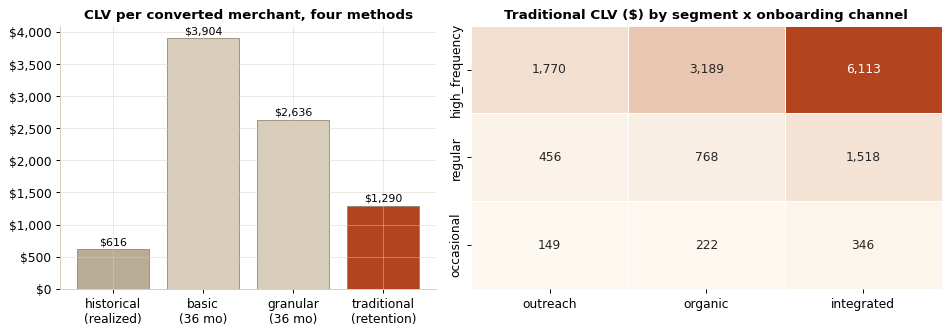

       segment    channel      clv  monthly_retention  rev_per_enrolled_month  merchants
    occasional   outreach  148.901              0.968                   4.908        806
    occasional    organic  221.567              0.978                   4.931        538
    occasional integrated  346.340              0.986                   5.052        385
       regular   outreach  456.450              0.913                  43.706        618
       regular    organic  768.454              0.946                  43.588        433
       regular integrated 1517.563              0.972                  43.776        332
high_frequency   outreach 1769.759              0.824                 377.142        367
high_frequency    organic 3189.309              0.892                 387.486        235
high_frequency integrated 6112.804              0.938                 405.974        178


In [8]:
def traditional_clv(g_merchants, g_pay):
    at_risk = (g_merchants.dur + g_merchants.churned).sum()      # at-risk merchant-months
    hazard = g_merchants.churned.sum() / at_risk                 # monthly churn rate
    retention_rate = 1 - hazard
    rev_per_enrolled_month = g_pay.net_revenue.sum() / g_merchants.dur.clip(lower=1).sum()
    return rev_per_enrolled_month * retention_rate / hazard, retention_rate, rev_per_enrolled_month

clv_trad, ret_all, rev_all = traditional_clv(merchants, pay)
print(f'Blended: ${rev_all:,.2f}/enrolled month x {ret_all:.3f}/{1-ret_all:.3f} = ${clv_trad:,.0f}')

rows = []
for seg in ['occasional', 'regular', 'high_frequency']:
    for ch in ['outreach', 'organic', 'integrated']:
        gm = merchants[(merchants.segment == seg) & (merchants.onboarding_channel == ch)]
        gp = pay[(pay.segment == seg) & (pay.onboarding_channel == ch)]
        clv, ret, rev = traditional_clv(gm, gp)
        rows.append({'segment': seg, 'channel': ch, 'clv': clv, 'monthly_retention': ret,
                     'rev_per_enrolled_month': rev, 'merchants': len(gm)})
clv_matrix = pd.DataFrame(rows)
pivot = clv_matrix.pivot(index='segment', columns='channel', values='clv') \
                  .reindex(['high_frequency', 'regular', 'occasional'])[['outreach', 'organic', 'integrated']]

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.9), gridspec_kw={'width_ratios': [1, 1.25]})
methods = {'historical\n(realized)': hist_clv.mean(), 'basic\n(36 mo)': clv_basic,
           'granular\n(36 mo)': clv_granular, 'traditional\n(retention)': clv_trad}
bars = axes[0].bar(methods.keys(), methods.values(), color=[MUTED, RULE, RULE, ACCENT], edgecolor=SECONDARY, lw=0.6)
axes[0].bar_label(bars, labels=[f'${v:,.0f}' for v in methods.values()], padding=2, fontsize=9)
axes[0].set_title('CLV per converted merchant, four methods')
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap=CMAP, cbar=False,
            linewidths=0.6, linecolor='white', ax=axes[1], annot_kws={'size': 10})
axes[1].set_title('Traditional CLV ($) by segment x onboarding channel')
axes[1].set_xlabel(''); axes[1].set_ylabel(''); axes[1].grid(False)
fig.tight_layout(); fig.savefig(IMG / 'clv-matrix.png', dpi=100, bbox_inches='tight'); plt.show()

print(clv_matrix.round(3).to_string(index=False))

## 8. Where the traditional formula breaks

The source material's own warning, worth seeing rather than reciting: the formula assumes churn is definitive (the merchant "dies") and it is not robust at low retention, where it under-reports value. On this rail the assumption is close to true (a merchant reverted to check rarely comes back without a new campaign, and re-conversions are excluded from this dataset), but the sensitivity matters because the segments sit on very different parts of the curve.

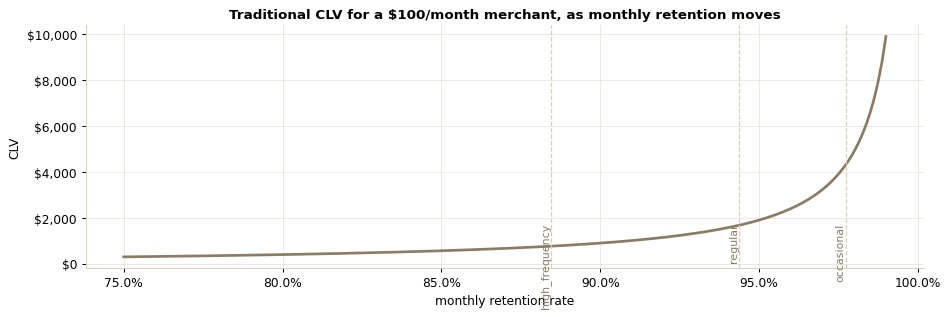

The same $100/month merchant is worth ~$300 at 75% monthly retention and ~$9,900 at 99%: value on a rail is a retention story before it is a volume story.


In [9]:
r = np.linspace(0.75, 0.99, 200)
fig, ax = plt.subplots(figsize=(10.9, 3.7))
ax.plot(r, 100 * r / (1 - r), color=SECONDARY, lw=2.2)
for seg, row in clv_matrix.groupby('segment').agg({'monthly_retention': 'mean'}).iterrows():
    ax.axvline(row.monthly_retention, color=RULE, lw=1, ls='--')
    ax.annotate(seg, (row.monthly_retention, 100 * 0.97 / 0.03 * 0.55), rotation=90,
                fontsize=9, color=SECONDARY, ha='right', va='top')
ax.set_title('Traditional CLV for a $100/month merchant, as monthly retention moves')
ax.set_xlabel('monthly retention rate'); ax.set_ylabel('CLV')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
fig.tight_layout(); plt.show()

print('The same $100/month merchant is worth ~$300 at 75% monthly retention and ~$9,900 at 99%: '
      'value on a rail is a retention story before it is a volume story.')

## 9. The number the business wanted: conversion spend ceilings

The source material states the goal of CLV plainly: benchmark customers and identify the maximum investment into acquiring one. Translated to this program: how much can each channel spend converting each segment before the conversion destroys value?

Cost assumptions per convert (fully loaded): outreach $250 (SDR labor plus onboarding incentive), organic $50 (self-serve enablement), integrated $180 (amortized AP-platform integration work). The decision table compares them to traditional CLV and adds payback in months.

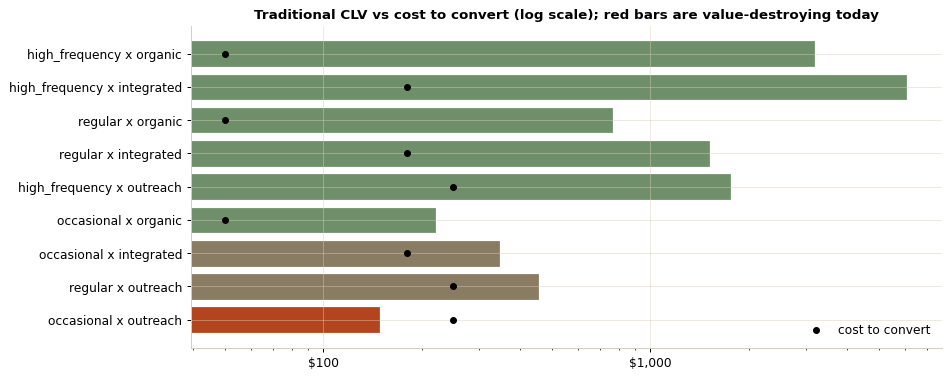

       segment    channel    clv  cost  clv_to_cost  payback_months  merchants
high_frequency    organic 3189.3    50         63.8             0.1        235
high_frequency integrated 6112.8   180         34.0             0.4        178
       regular    organic  768.5    50         15.4             1.1        433
       regular integrated 1517.6   180          8.4             4.1        332
high_frequency   outreach 1769.8   250          7.1             0.7        367
    occasional    organic  221.6    50          4.4            10.1        538
    occasional integrated  346.3   180          1.9            35.6        385
       regular   outreach  456.4   250          1.8             5.7        618
    occasional   outreach  148.9   250          0.6            50.9        806

Underwater: occasional converted via outreach returns $149 against $250 to convert.


In [10]:
COST = {'outreach': 250, 'organic': 50, 'integrated': 180}
decision = clv_matrix.copy()
decision['cost'] = decision.channel.map(COST)
decision['clv_to_cost'] = decision.clv / decision.cost
decision['payback_months'] = decision.cost / decision.rev_per_enrolled_month
decision = decision.sort_values('clv_to_cost', ascending=False)

fig, ax = plt.subplots(figsize=(10.9, 4.4))
labels = decision.segment + ' x ' + decision.channel
colors = [ACCENT if c < 1 else (SECONDARY if c < 3 else '#6F8F6A') for c in decision.clv_to_cost]
bars = ax.barh(labels, decision.clv, color=colors, edgecolor='white')
ax.scatter(decision.cost, range(len(decision)), color='black', zorder=3, s=22, label='cost to convert')
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Traditional CLV vs cost to convert (log scale); red bars are value-destroying today')
ax.invert_yaxis(); ax.legend(frameon=False, loc='lower right')
fig.tight_layout(); fig.savefig(IMG / 'cac-ceilings.png', dpi=100, bbox_inches='tight'); plt.show()

cols = ['segment', 'channel', 'clv', 'cost', 'clv_to_cost', 'payback_months', 'merchants']
print(decision[cols].round(1).to_string(index=False))
under = decision[decision.clv_to_cost < 1]
print()
for _, r0 in under.iterrows():
    print(f'Underwater: {r0.segment} converted via {r0.channel} returns ${r0.clv:,.0f} '
          f'against ${r0.cost:,.0f} to convert.')

## 10. RFM features for next-month revenue

Formulas price the average merchant; operations wants a number per merchant. Following the source material's preparation recipe:

1. Pick a snapshot: December 2025 is the target month and is excluded from features entirely.
2. Population: merchants enrolled at the snapshot with at least one month of possible history.
3. Features over the trailing 12 months: **recency** (months since last settled payment, capped at 13 for the never-active), **frequency** (payments in the window), **monetary** (net revenue in the window), plus tenure and dummy-encoded onboarding channel and prior rail.
4. Target: December 2025 net revenue, zero for enrolled merchants that settled nothing.

One deliberate exclusion: the segment label. Segment is assigned from payment behavior, so feeding it to a model alongside the behavioral features it was derived from is label leakage dressed as a predictor. It also demonstrates the p-value trap: with segment dummies included, R-squared rises to 0.70 but every RFM coefficient goes statistically dead, because the dummies and the behavior are collinear. The RFM features should carry the signal on their own; that is the entire premise of the approach.

The zeros in the target are also why MAPE (mean absolute percentage error) is unusable here, exactly the caveat the source flags: percentage error is undefined when actuals are zero.

1,974 merchants enrolled at the snapshot | 40% settled nothing in the target month


,recency_months,frequency_12m,monetary_12m,tenure_months,onboarding_channel_organic,onboarding_channel_outreach,converted_from_Check,target_next_month
0,1,20.0,604.6032,35,0.0,1.0,1.0,149.4178
9,1,21.0,591.2447,35,0.0,1.0,0.0,64.0101
10,3,7.0,73.8786,35,0.0,1.0,1.0,42.6097
12,1,7.0,57.8556,35,0.0,1.0,1.0,3.7494
14,1,6.0,34.0964,35,0.0,1.0,0.0,0.0000


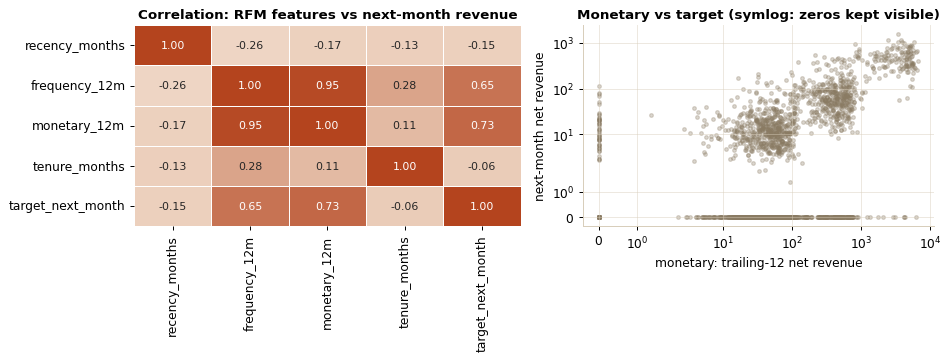

In [11]:
SNAPSHOT = pd.Period('2025-12', freq='M')
WINDOW = 12

pop = merchants[(merchants.conv < SNAPSHOT) &
                (~merchants.churned | (merchants.churn >= SNAPSHOT))].copy()
hist_w = pay[(pay.month >= SNAPSHOT - WINDOW) & (pay.month < SNAPSHOT)]

last_active = pay[pay.month < SNAPSHOT].groupby('merchant_id').month.max()
la = pop.merchant_id.map(last_active)
pop['recency_months'] = [(SNAPSHOT - x).n if pd.notna(x) else WINDOW + 1 for x in la]
pop['frequency_12m'] = pop.merchant_id.map(hist_w.groupby('merchant_id').payments.sum()).fillna(0.0)
pop['monetary_12m'] = pop.merchant_id.map(hist_w.groupby('merchant_id').net_revenue.sum()).fillna(0.0)
pop['tenure_months'] = [(SNAPSHOT - c).n for c in pop.conv]
target_rev = pay[pay.month == SNAPSHOT].groupby('merchant_id').net_revenue.sum()
pop['target_next_month'] = pop.merchant_id.map(target_rev).fillna(0.0)

dummies = pd.get_dummies(pop[['onboarding_channel', 'converted_from']],
                         drop_first=True).astype(float)
features = pd.concat(
    [pop[['recency_months', 'frequency_12m', 'monetary_12m', 'tenure_months']], dummies], axis=1)

print(f'{len(pop):,} merchants enrolled at the snapshot | '
      f'{(pop.target_next_month == 0).mean():.0%} settled nothing in the target month')
display(pd.concat([features, pop.target_next_month], axis=1).head())

corr = pd.concat([pop[['recency_months', 'frequency_12m', 'monetary_12m',
                       'tenure_months', 'target_next_month']]], axis=1).corr()
fig, axes = plt.subplots(1, 2, figsize=(10.9, 4.2), gridspec_kw={'width_ratios': [1.1, 1]})
sns.heatmap(corr, annot=True, fmt='.2f', cmap=CMAP, vmin=-1, vmax=1, cbar=False,
            linewidths=0.6, linecolor='white', ax=axes[0], annot_kws={'size': 9})
axes[0].set_title('Correlation: RFM features vs next-month revenue'); axes[0].grid(False)
axes[1].scatter(pop.monetary_12m, pop.target_next_month, s=9, alpha=0.3, color=SECONDARY)
axes[1].set_xscale('symlog'); axes[1].set_yscale('symlog')
axes[1].set_xlabel('monetary: trailing-12 net revenue'); axes[1].set_ylabel('next-month net revenue')
axes[1].set_title('Monetary vs target (symlog: zeros kept visible)')
fig.tight_layout(); plt.show()

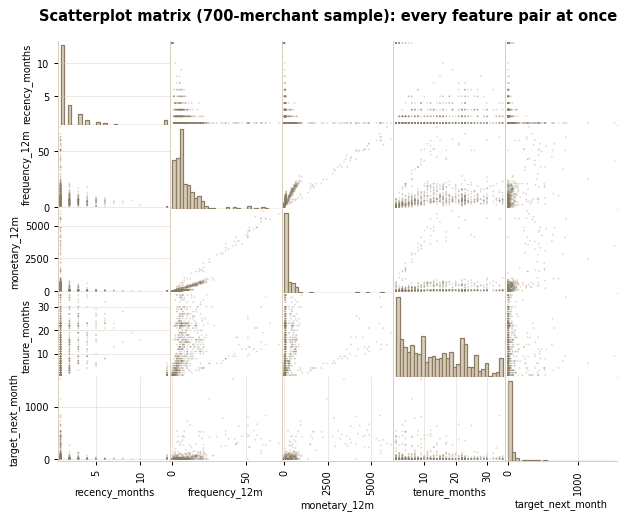

In [12]:
sample = pop.sample(700, random_state=7)
axes = pd.plotting.scatter_matrix(
    sample[['recency_months', 'frequency_12m', 'monetary_12m', 'tenure_months', 'target_next_month']],
    figsize=(8.2, 6.2), s=8, alpha=0.3, color=SECONDARY,
    hist_kwds={'bins': 30, 'color': RULE, 'edgecolor': SECONDARY})
for ax in axes.ravel():
    ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
plt.suptitle('Scatterplot matrix (700-merchant sample): every feature pair at once', y=0.94, fontweight='bold')
plt.show()

## 11. Linear regression: fit and honest evaluation

The source material's modeling steps, in order: split to training and testing, initialize, fit on training, predict on testing, measure on testing. A 75/25 random split, then RMSE and MAE on both sides: a large train-test gap would flag overfitting. The model must also beat a benchmark that costs nothing: "next month equals last month". If it cannot, the features are decoration.

RMSE train $104 | test $75
MAE  train $50 | test $41
No overfitting signal: test error is not worse than train (the heaviest settlers happened to land in the training split, so the direction runs the other way).
Benchmark "December = November": RMSE $91 -> the model beats it by 17%, partly because November under-predicts a seasonal December.
MAPE is skipped: 40% of target values are zero, and percentage error is undefined at zero.


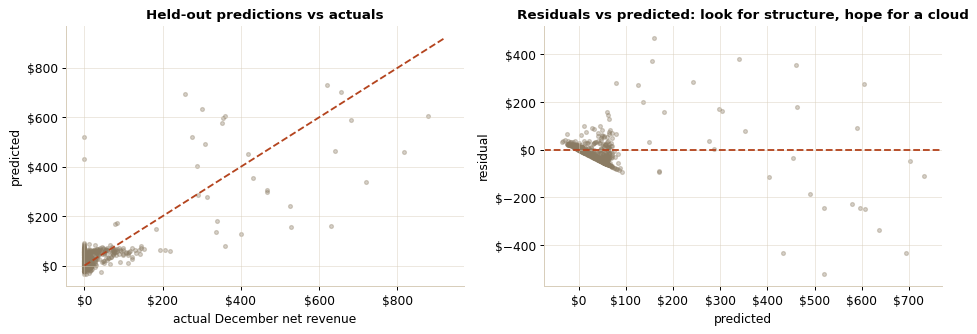

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

X, Y = features, pop.target_next_month
train_X, test_X, train_Y, test_Y = train_test_split(X, Y, test_size=0.25, random_state=99)

linreg = LinearRegression().fit(train_X, train_Y)
train_pred = linreg.predict(train_X)
test_pred = linreg.predict(test_X)

rmse_train = np.sqrt(mean_squared_error(train_Y, train_pred))
rmse_test = np.sqrt(mean_squared_error(test_Y, test_pred))
mae_train = mean_absolute_error(train_Y, train_pred)
mae_test = mean_absolute_error(test_Y, test_pred)

nov_rev = pay[pay.month == SNAPSHOT - 1].groupby('merchant_id').net_revenue.sum()
naive_pred = pop.loc[test_Y.index, 'merchant_id'].map(nov_rev).fillna(0.0)
rmse_naive = np.sqrt(mean_squared_error(test_Y, naive_pred))

print(f'RMSE train ${rmse_train:,.0f} | test ${rmse_test:,.0f}')
print(f'MAE  train ${mae_train:,.0f} | test ${mae_test:,.0f}')
print('No overfitting signal: test error is not worse than train (the heaviest settlers happened '
      'to land in the training split, so the direction runs the other way).')
print(f'Benchmark "December = November": RMSE ${rmse_naive:,.0f} -> the model beats it by '
      f'{(1 - rmse_test/rmse_naive):.0%}, partly because November under-predicts a seasonal December.')
print('MAPE is skipped: 40% of target values are zero, and percentage error is undefined at zero.')

fig, axes = plt.subplots(1, 2, figsize=(10.9, 3.9))
lim = max(test_Y.max(), test_pred.max()) * 1.05
axes[0].scatter(test_Y, test_pred, s=10, alpha=0.35, color=SECONDARY)
axes[0].plot([0, lim], [0, lim], color=ACCENT, lw=1.5, ls='--')
axes[0].set_xlabel('actual December net revenue'); axes[0].set_ylabel('predicted')
axes[0].set_title('Held-out predictions vs actuals')
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
resid = test_Y - test_pred
axes[1].scatter(test_pred, resid, s=10, alpha=0.35, color=SECONDARY)
axes[1].axhline(0, color=ACCENT, lw=1.5, ls='--')
axes[1].set_xlabel('predicted'); axes[1].set_ylabel('residual')
axes[1].set_title('Residuals vs predicted: look for structure, hope for a cloud')
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
fig.tight_layout(); fig.savefig(IMG / 'model-fit.png', dpi=100, bbox_inches='tight'); plt.show()

## 12. Reading the coefficients with statsmodels

scikit-learn fits; statsmodels explains. The ordinary least squares (OLS) summary adds what the business review needs: R-squared (share of variance explained) and a p-value per coefficient (probability the coefficient appears by chance; 5% and 1% are the usual thresholds).

The summary below contains a trap worth reading slowly: the frequency coefficient comes out **negative**, as if settling more payments predicted less revenue. It does not. Frequency and monetary are correlated at r = 0.95, so OLS answers a conditional question: holding trailing-12 revenue fixed, more payments means smaller payments. That is multicollinearity, and the fix is the one the regression chapter of every good textbook prescribes: remove the redundant predictor and watch the coefficients stabilize. Prediction quality barely moves; interpretability recovers.

A note the source makes that fits this data: if the target were December payment **counts** rather than revenue, count regressions (Poisson or negative binomial) would be the better tool.

In [14]:
import statsmodels.api as sm

X_sm = sm.add_constant(train_X.astype(float))
ols = sm.OLS(np.asarray(train_Y, dtype=float), X_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     262.0
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          2.54e-253
Time:                        16:01:36   Log-Likelihood:                -8975.0
No. Observations:                1480   AIC:                         1.797e+04
Df Residuals:                    1472   BIC:                         1.801e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

                             coef (full)  p (full)  coef (no frequency)  p (no frequency)
const                            71.2385    0.0000              56.8682            0.0000
converted_from_Check             -1.5863    0.7770              -1.8671            0.7404
frequency_12m                    -3.9660    0.0000                  NaN               NaN
monetary_12m                      0.1489    0.0000               0.1094            0.0000
onboarding_channel_organic        0.4904    0.9438               1.3419            0.8478
onboarding_channel_outreach      -1.7846    0.7878              -1.1595            0.8619
recency_months                   -4.4057    0.0000              -2.9637            0.0042
tenure_months                    -1.8090    0.0000              -2.6004            0.0000

R-squared: 0.555 full vs 0.549 without frequency: nothing of substance was lost.


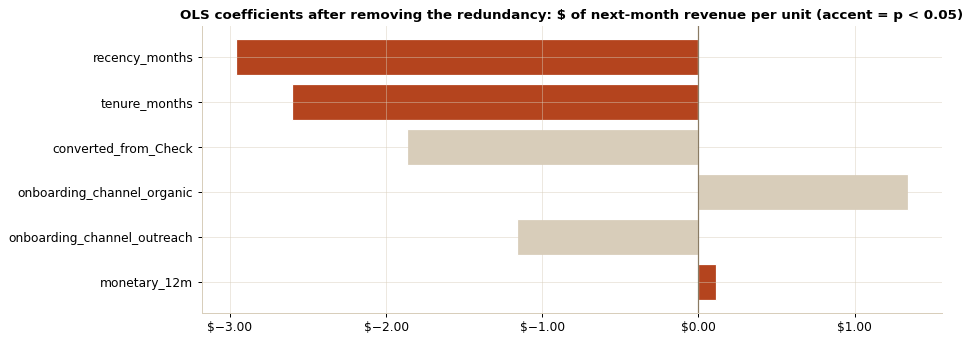

Significant at 5%: recency_months, monetary_12m, tenure_months
The read: every dollar of trailing-12 revenue predicts about $11 per $100 of next-month revenue, each month of recency costs $2.96, and channel dummies are noise once behavior is known: channel decides who churns (section 3), not what survivors settle.


In [15]:
# drop the redundant predictor and refit: the multicollinearity fix
X2 = train_X.drop(columns=['frequency_12m'])
ols2 = sm.OLS(np.asarray(train_Y, dtype=float), sm.add_constant(X2.astype(float))).fit()

compare = pd.DataFrame({
    'coef (full)': ols.params, 'p (full)': ols.pvalues,
    'coef (no frequency)': ols2.params, 'p (no frequency)': ols2.pvalues,
}).round(4)
print(compare.to_string())
print(f'\nR-squared: {ols.rsquared:.3f} full vs {ols2.rsquared:.3f} without frequency: '
      'nothing of substance was lost.')

params = ols2.params.drop('const')
pvals = ols2.pvalues.drop('const')
order2 = params.abs().sort_values().index
fig, ax = plt.subplots(figsize=(10.9, 4.0))
colors = [ACCENT if pvals[k] < 0.05 else RULE for k in order2]
ax.barh(order2, params[order2], color=colors, edgecolor='white')
ax.axvline(0, color=SECONDARY, lw=1)
ax.set_title('OLS coefficients after removing the redundancy: $ of next-month revenue per unit (accent = p < 0.05)')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.2f}'))
fig.tight_layout(); plt.show()

sig = pvals[pvals < 0.05].index.tolist()
print('Significant at 5%:', ', '.join(sig))
print('The read: every dollar of trailing-12 revenue predicts about '
      f'${ols2.params["monetary_12m"]*100:.0f} per $100 of next-month revenue, each month of recency '
      f'costs ${-ols2.params["recency_months"]:,.2f}, and channel dummies are noise once behavior is '
      'known: channel decides who churns (section 3), not what survivors settle.')

## Takeaways

1. **How long do we keep them?** Median rail tenure is the retention headline: high_frequency merchants pay the most per month and leave the fastest, integrated converts barely leave at all, and the 2024 campaign cohorts are visibly weaker in the heatmap. Tenure, not volume, is where rail economics are decided.
2. **What is a convert worth?** The four CLV methods disagree on purpose: historical is a floor, the 36-month lifespan formulas are optimistic by construction, and the traditional retention-based estimate is the one fit for spend decisions on a rail where reversion is effectively final.
3. **Where should conversion dollars go?** The CLV-to-cost table is the deliverable: integrated conversions repay their cost many times over in every segment, while paid outreach against occasional merchants destroys value at current costs. The ceiling per channel and segment is now an explicit number instead of a feeling.
4. **Per-merchant prediction works with three features.** Monetary history and recency carry the next-month revenue model; it beats the "same as last month" benchmark on held-out data. Frequency, correlated 0.95 with monetary, adds a sign-flipped coefficient instead of signal, and removing it is the difference between a model that predicts and a model that can also be explained in a business review.

Next steps that would earn their keep: discount future months to present value (the retention/churn ratio makes it a one-line change), replace the single hazard with a probabilistic lifetime model (BG/NBD, which drops the "churn is observed" assumption), and test whether conversion incentives shift the survival curve enough to pay for themselves (an uplift question, not a CLV question).